In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

# Fund Performance Analytics

This notebook analyzes the performance of mutual funds using NAV data.

Metrics:
- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha
- Beta
- Maximum Drawdown

In [2]:
df = pd.read_csv("../Data/Raw/118632_nav.csv")

df.head()

,date,nav
0,23-07-2026,99.7294
1,22-07-2026,100.0997
2,21-07-2026,101.0669
3,20-07-2026,101.3229
4,17-07-2026,101.8020


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3335 entries, 0 to 3334
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3335 non-null   object 
 1   nav     3335 non-null   float64
dtypes: float64(1), object(1)
memory usage: 52.2+ KB
None


In [4]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3335 entries, 0 to 3334
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3335 non-null   datetime64[ns]
 1   nav     3335 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 52.2 KB


In [5]:
df = df.sort_values("date")

df.head()

,date,nav
3334,2013-01-02,14.6967
3333,2013-01-03,14.7305
3332,2013-01-04,14.8037
3331,2013-01-07,14.7718
3330,2013-01-08,14.7197


In [6]:
df["daily_return"] = df["nav"].pct_change()

df.head()

,date,nav,daily_return
3334,2013-01-02,14.6967,NaN
3333,2013-01-03,14.7305,0.002300
3332,2013-01-04,14.8037,0.004969
3331,2013-01-07,14.7718,-0.002155
3330,2013-01-08,14.7197,-0.003527


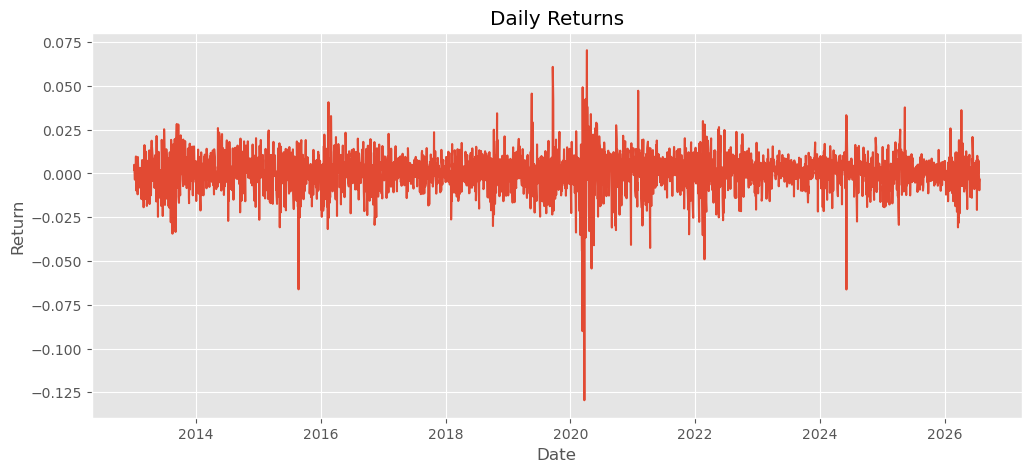

In [7]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["daily_return"])

plt.title("Daily Returns")

plt.xlabel("Date")

plt.ylabel("Return")

plt.show()

In [8]:
latest_date = df["date"].max()
latest_nav = df["nav"].iloc[-1]

print("Latest Date:", latest_date)
print("Latest NAV:", latest_nav)

Latest Date: 2026-07-23 00:00:00
Latest NAV: 99.7294


In [9]:
def calculate_cagr(data, years):

    end_date = data["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    filtered = data[data["date"] >= start_date]

    if len(filtered) < 2:
        return None

    start_nav = filtered.iloc[0]["nav"]
    end_nav = filtered.iloc[-1]["nav"]

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    return cagr * 100

In [10]:
cagr_1 = calculate_cagr(df, 1)
cagr_3 = calculate_cagr(df, 3)
cagr_5 = calculate_cagr(df, 5)

print("1 Year CAGR :", round(cagr_1, 2), "%")
print("3 Year CAGR :", round(cagr_3, 2), "%")
print("5 Year CAGR :", round(cagr_5, 2), "%")

1 Year CAGR : -2.02 %
3 Year CAGR : 12.52 %
5 Year CAGR : 15.62 %


In [11]:
risk_free_rate = 0.065

daily_rf = risk_free_rate / 252

excess_return = df["daily_return"] - daily_rf

sharpe_ratio = (excess_return.mean() / excess_return.std()) * np.sqrt(252)

print("Sharpe Ratio:", round(sharpe_ratio, 2))

Sharpe Ratio: 0.56


In [12]:
# Downside returns (only negative returns)
downside_returns = df["daily_return"][df["daily_return"] < 0]

# Downside deviation
downside_std = downside_returns.std()

# Average excess return
average_excess_return = excess_return.mean()

# Sortino Ratio
sortino_ratio = (average_excess_return / downside_std) * np.sqrt(252)

print("Sortino Ratio:", round(sortino_ratio, 2))

Sortino Ratio: 0.7


In [13]:
# Running maximum NAV
df["running_max"] = df["nav"].cummax()

# Drawdown
df["drawdown"] = (df["nav"] / df["running_max"]) - 1

# Maximum Drawdown
max_drawdown = df["drawdown"].min()

print("Maximum Drawdown:", round(max_drawdown * 100, 2), "%")

Maximum Drawdown: -39.96 %


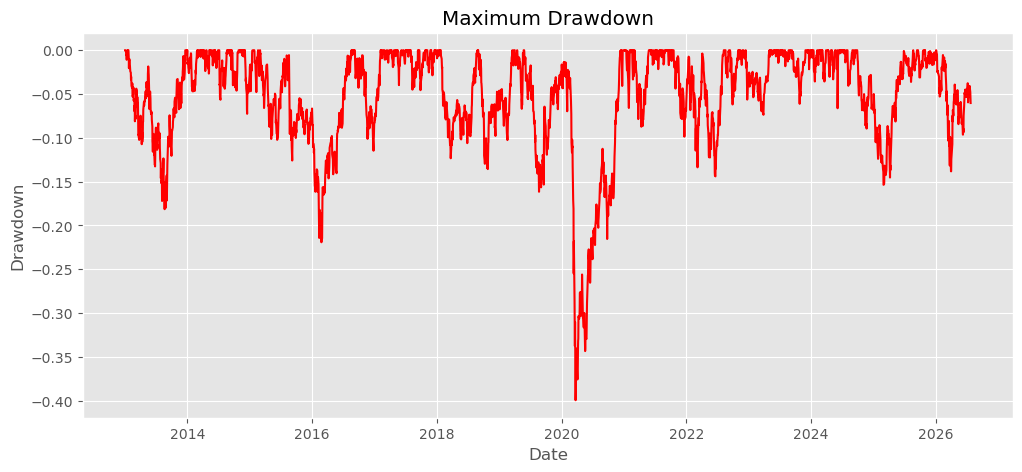

In [14]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["drawdown"], color="red")

plt.title("Maximum Drawdown")

plt.xlabel("Date")

plt.ylabel("Drawdown")

plt.grid(True)

plt.show()

In [15]:
performance = pd.DataFrame({
    "Metric": [
        "1 Year CAGR",
        "3 Year CAGR",
        "5 Year CAGR",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Maximum Drawdown"
    ],
    "Value": [
        cagr_1,
        cagr_3,
        cagr_5,
        sharpe_ratio,
        sortino_ratio,
        max_drawdown
    ]
})

performance

,Metric,Value
0,1 Year CAGR,-2.023786
1,3 Year CAGR,12.520055
2,5 Year CAGR,15.622778
3,Sharpe Ratio,0.562851
4,Sortino Ratio,0.698028
5,Maximum Drawdown,-0.399608


In [16]:
performance.to_csv("../Reports/fund_performance_metrics.csv", index=False)

print("Saved Successfully!")

Saved Successfully!


In [18]:
import pandas as pd

benchmark = pd.read_csv(
    "../Data/Raw/drive-download-20260724T173806Z-1-001/10_benchmark_indices.csv"
)

print(benchmark.head())
print(benchmark.columns)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
Index(['date', 'index_name', 'close_value'], dtype='object')


In [19]:
import pandas as pd

# Load benchmark data
benchmark = pd.read_csv("../Data/Raw/drive-download-20260724T173806Z-1-001/10_benchmark_indices.csv")

# Convert date to datetime
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Keep only NIFTY100
benchmark = benchmark[benchmark["index_name"] == "NIFTY100"]

# Sort by date
benchmark = benchmark.sort_values("date")

# Calculate daily return
benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

benchmark.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [20]:
# Merge fund and benchmark on date
merged = pd.merge(
    df,
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,date,nav,daily_return,running_max,drawdown,benchmark_return
0,2022-01-03,54.3991,0.014710,57.047,-0.046416,NaN
1,2022-01-04,54.9154,0.009491,57.047,-0.037366,-0.013540
2,2022-01-05,55.1480,0.004236,57.047,-0.033288,0.004003
3,2022-01-06,54.8331,-0.005710,57.047,-0.038808,-0.002935
4,2022-01-07,54.8875,0.000992,57.047,-0.037855,0.006150


In [22]:
print(merged[["daily_return", "benchmark_return"]].isnull().sum())
print(merged.shape)

daily_return        0
benchmark_return    1
dtype: int64
(1082, 6)


In [23]:
merged_clean = merged[["daily_return", "benchmark_return"]].dropna()

print(merged_clean.shape)
merged_clean.head()

(1081, 2)


,daily_return,benchmark_return
1,0.009491,-0.013540
2,0.004236,0.004003
3,-0.005710,-0.002935
4,0.000992,0.006150
5,0.011921,-0.008351


In [24]:
import numpy as np

beta = np.cov(
    merged_clean["daily_return"],
    merged_clean["benchmark_return"]
)[0, 1] / np.var(merged_clean["benchmark_return"])

print("Beta:", round(beta, 4))

Beta: -0.011


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [27]:
folder = "../Data/Raw/drive-download-20260724T173806Z-1-001"

nav_files = [f for f in os.listdir(folder) if f.endswith("_nav.csv")]

print(nav_files)

[]


In [28]:
import os

print(os.getcwd())

c:\Users\sanal\OneDrive\Desktop\MutualFund Analytics(Internship)\notebooks


In [29]:
import os

print(os.listdir("../Data/Raw"))

['118632_nav.csv', '119092_nav.csv', '119551_nav.csv', '120503_nav.csv', '120841_nav.csv', '125497_nav.csv', 'drive-download-20260724T173806Z-1-001', 'drive-download-20260724T173806Z-1-001.zip', 'investor_transactions_cleaned.csv']


In [30]:
import os

folder = "../Data/Raw/drive-download-20260724T173806Z-1-001"

print(os.listdir(folder))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Bluestock_MF_Capstone_Project.pdf']


In [31]:
import os

folder = "../Data/Raw"

nav_files = [f for f in os.listdir(folder) if f.endswith("_nav.csv")]

print(nav_files)

['118632_nav.csv', '119092_nav.csv', '119551_nav.csv', '120503_nav.csv', '120841_nav.csv', '125497_nav.csv']


In [32]:
results = []

for file in nav_files:

    df = pd.read_csv(folder + "/" + file)

    df["date"] = pd.to_datetime(df["date"], dayfirst=True)

    df = df.sort_values("date")

    df["daily_return"] = df["nav"].pct_change()

    print("\n", file)
    print(df.head())


 118632_nav.csv
           date      nav  daily_return
3334 2013-01-02  14.6967           NaN
3333 2013-01-03  14.7305      0.002300
3332 2013-01-04  14.8037      0.004969
3331 2013-01-07  14.7718     -0.002155
3330 2013-01-08  14.7197     -0.003527

 119092_nav.csv
           date      nav  daily_return
3601 2012-12-31  23.9920           NaN
3600 2013-01-01  23.9979      0.000246
3599 2013-01-02  24.0036      0.000238
3598 2013-01-03  24.0092      0.000233
3597 2013-01-04  24.0147      0.000229

 119551_nav.csv
           date       nav  daily_return
3272 2013-01-02  103.0059           NaN
3271 2013-01-03  103.0306      0.000240
3270 2013-01-04  103.0619      0.000304
3269 2013-01-07  103.1408      0.000766
3268 2013-01-08  103.1663      0.000247

 120503_nav.csv
           date      nav  daily_return
3343 2013-01-02  15.0253           NaN
3342 2013-01-03  15.0737      0.003221
3341 2013-01-04  15.0702     -0.000232
3340 2013-01-07  15.0913      0.001400
3339 2013-01-08  15.1146     

In [33]:
results = []

for file in nav_files:

    df = pd.read_csv(folder + "/" + file)

    df["date"] = pd.to_datetime(df["date"], dayfirst=True)
    df = df.sort_values("date")

    # Daily Return
    df["daily_return"] = df["nav"].pct_change()

    # CAGR
    years = (df["date"].max() - df["date"].min()).days / 365
    cagr = ((df["nav"].iloc[-1] / df["nav"].iloc[0]) ** (1 / years)) - 1

    # Sharpe Ratio
    risk_free_rate = 0.065
    sharpe = ((df["daily_return"].mean() * 252) - risk_free_rate) / (df["daily_return"].std() * np.sqrt(252))

    # Sortino Ratio
    downside = df[df["daily_return"] < 0]["daily_return"]

    if len(downside) > 0:
        sortino = ((df["daily_return"].mean() * 252) - risk_free_rate) / (downside.std() * np.sqrt(252))
    else:
        sortino = np.nan

    # Maximum Drawdown
    running_max = df["nav"].cummax()
    drawdown = (df["nav"] / running_max) - 1
    max_drawdown = drawdown.min()

    results.append({
        "Fund": file.replace("_nav.csv", ""),
        "CAGR": round(cagr * 100, 2),
        "Sharpe Ratio": round(sharpe, 2),
        "Sortino Ratio": round(sortino, 2),
        "Max Drawdown": round(max_drawdown * 100, 2)
    })

In [34]:
scorecard = pd.DataFrame(results)

scorecard

,Fund,CAGR,Sharpe Ratio,Sortino Ratio,Max Drawdown
0,118632,15.16,0.56,0.70,-39.96
1,119092,50.67,0.26,656.94,-1.39
2,119551,0.25,-0.67,-0.38,-36.65
3,120503,15.70,NaN,inf,-100.00
4,120841,16.73,0.68,0.80,-33.43
5,125497,24.25,1.11,1.35,-40.26


In [35]:
scorecard.to_csv("../Data/processed/fund_scorecard.csv", index=False)

print("Fund Scorecard Saved Successfully!")

Fund Scorecard Saved Successfully!


In [36]:
# Load benchmark data
benchmark = pd.read_csv("../Data/Raw/drive-download-20260724T173806Z-1-001/10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])
benchmark = benchmark[benchmark["index_name"] == "NIFTY100"]
benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

In [37]:
alpha_beta_results = []

for file in nav_files:

    df = pd.read_csv(folder + "/" + file)

    df["date"] = pd.to_datetime(df["date"], dayfirst=True)
    df = df.sort_values("date")

    df["daily_return"] = df["nav"].pct_change()

    merged = pd.merge(
        df,
        benchmark[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged[["daily_return", "benchmark_return"]].dropna()

    if len(merged) < 2:
        continue

    beta = np.cov(
        merged["daily_return"],
        merged["benchmark_return"]
    )[0, 1] / np.var(merged["benchmark_return"])

    risk_free = 0.065

    fund_return = merged["daily_return"].mean() * 252
    benchmark_return = merged["benchmark_return"].mean() * 252

    alpha = fund_return - (
        risk_free + beta * (benchmark_return - risk_free)
    )

    alpha_beta_results.append({
        "Fund": file.replace("_nav.csv", ""),
        "Alpha": round(alpha, 4),
        "Beta": round(beta, 4)
    })

In [38]:
alpha_beta = pd.DataFrame(alpha_beta_results)

alpha_beta

,Fund,Alpha,Beta
0,118632,0.0830,-0.0110
1,119092,0.0034,-0.0005
2,119551,-0.0928,-0.0018
3,120503,0.0003,-0.0012
4,120841,0.1098,0.0316
5,125497,0.0605,-0.0011


In [39]:
alpha_beta.to_csv("../Data/processed/alpha_beta.csv", index=False)

print("Alpha & Beta Saved Successfully!")

Alpha & Beta Saved Successfully!


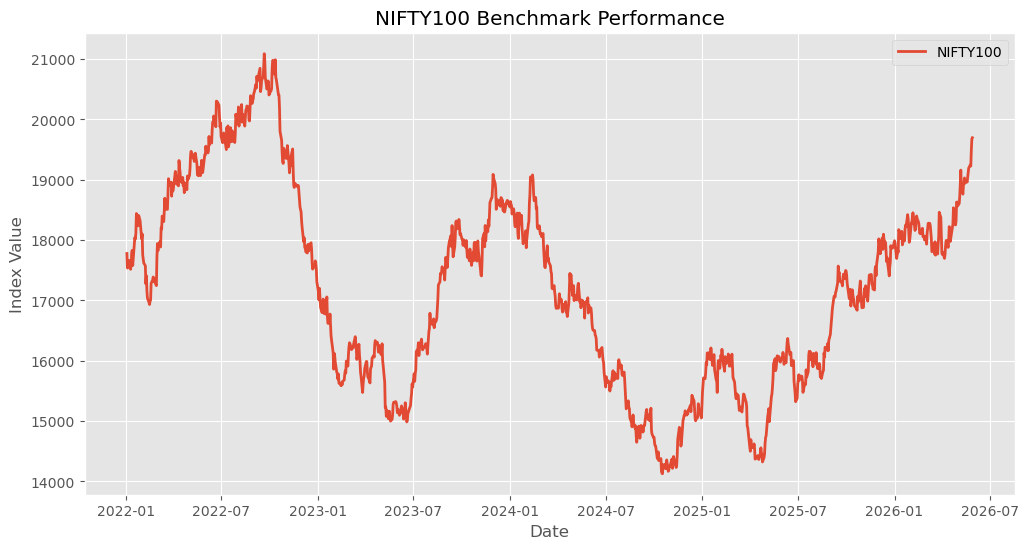

In [40]:
plt.figure(figsize=(12,6))

plt.plot(
    benchmark["date"],
    benchmark["close_value"],
    label="NIFTY100",
    linewidth=2
)

plt.title("NIFTY100 Benchmark Performance")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.grid(True)

plt.show()

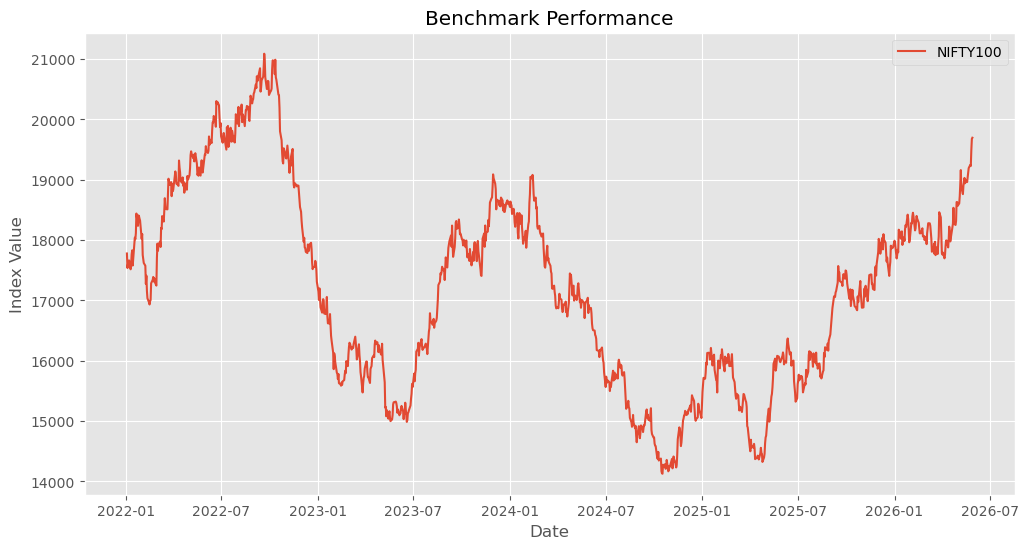

Benchmark chart saved successfully!


In [41]:
plt.figure(figsize=(12,6))

plt.plot(
    benchmark["date"],
    benchmark["close_value"],
    label="NIFTY100"
)

plt.title("Benchmark Performance")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.grid(True)

# Save chart
plt.savefig("../Reports/benchmark_comparison.png")

plt.show()

print("Benchmark chart saved successfully!")